In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
stop_words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"])

In [ ]:
def clean_text(text):
    text = text.lower()                                 # Chữ thường
    text = re.sub(r'<.*?>', ' ', text)                  # Xóa HTML (VD: <br />)
    text = re.sub(r'[^a-zA-Z\s]', '', text)             # Xóa dấu câu, ký tự lạ
    text = re.sub(r'\s+', ' ', text).strip()            # Xóa khoảng trắng thừa

    # Loại bỏ các từ vô nghĩa (stopwords)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("Đang đọc file 'IMDB Dataset.csv'...")
df = pd.read_csv('/content/sample_data/IMDB Dataset.csv', header=None, engine='python', on_bad_lines='skip')
df.columns = ['review', 'sentiment']

print("Đang làm sạch văn bản (sẽ mất khoảng 1-2 phút)...")
df['clean_review'] = df['review'].apply(clean_text)

# Chuyển nhãn (sentiment) thành số: positive -> 1, negative -> 0
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

Đang đọc file 'IMDB Dataset.csv'...
Đang làm sạch văn bản (sẽ mất khoảng 1-2 phút)...


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'],
    df['label'],
    test_size=0.2,
    random_state=42
)
print(f"Số lượng câu Train: {len(X_train)} | Số lượng câu Test: {len(X_test)}")

Số lượng câu Train: 25940 | Số lượng câu Test: 6486


In [ ]:
MAX_VOCAB_SIZE = 10000   # Giữ lại 10.000 từ phổ biến nhất
MAX_SEQUENCE_LENGTH = 200  # Chiều dài chuẩn của mỗi câu

print("Đang mã hóa chữ thành ma trận số...")
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Chuyển chữ thành số
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Cắt/ghép độ dài các câu cho bằng đúng 200
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')

# Đưa nhãn về dạng Numpy Array để train bằng Keras
y_train = np.array(y_train)
y_test  = np.array(y_test)

print("HOÀN TẤT PIPELINE! Sẵn sàng đưa vào mô hình.")
print("- Kích thước ma trận Train:", X_train_pad.shape)
print("- Kích thước ma trận Test:", X_test_pad.shape)

Đang mã hóa chữ thành ma trận số...
HOÀN TẤT PIPELINE! Sẵn sàng đưa vào mô hình.
- Kích thước ma trận Train: (25940, 200)
- Kích thước ma trận Test: (6486, 200)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout, Layer
from IPython.display import HTML, display

In [ ]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        # Tạo các ma trận trọng số (Weights) có thể học được cho Attention
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # Tính điểm số chú ý (score)
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        # Dùng Softmax để ép các điểm số cộng lại bằng 1
        a = tf.keras.backend.softmax(e, axis=1)
        # Nhân trọng số với đầu ra của GRU
        output = x * a
        # Trả về Context Vector (để dự đoán) và Trọng số Attention (để vẽ hình)
        return tf.keras.backend.sum(output, axis=1), a

In [ ]:
print("Đang khởi tạo kiến trúc mô hình...")

# 1. Cổng vào
sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')

# 2. Lớp Nhúng từ (Biến số thành vector 128 chiều)
embedded_sequences = Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128)(sequence_input)

# 3. Lớp BiGRU (Đọc xuôi và ngược)
gru_out = Bidirectional(GRU(64, return_sequences=True))(embedded_sequences)

# 4. Lớp Attention (Tìm các từ quan trọng nhất)
context_vector, attention_weights = Attention()(gru_out)

# 5. Lớp phân loại (Kết luận)
dense_out = Dense(64, activation='relu')(context_vector)
dense_out = Dropout(0.5)(dense_out) # Tránh học vẹt (Overfitting)
preds = Dense(1, activation='sigmoid')(dense_out) # Đầu ra 0 hoặc 1

# Khai báo mô hình chính
model = Model(inputs=sequence_input, outputs=preds)

# Khai báo mô hình phụ (Chỉ dùng để trích xuất trọng số Attention để vẽ hình)
attention_extractor = Model(inputs=sequence_input, outputs=attention_weights)

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Đang khởi tạo kiến trúc mô hình...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ [(None, 128), (None,   │           328 │
│                                 │ 200, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,363,145 (5.20 MB)

 Trainable params: 1,363,145 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("\nBắt đầu huấn luyện... (Có thể đi pha ly cà phê nhé!)")
EPOCHS = 5 # Để 3 epochs chạy cho nhanh, nếu muốn kết quả siêu tốt hãy đổi thành 5
BATCH_SIZE = 128

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Bắt đầu huấn luyện... (Có thể đi pha ly cà phê nhé!)
Epoch 1/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.7620 - loss: 0.4578 - val_accuracy: 0.8757 - val_loss: 0.2972
Epoch 2/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9127 - loss: 0.2303 - val_accuracy: 0.8890 - val_loss: 0.2758
Epoch 3/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9404 - loss: 0.1672 - val_accuracy: 0.8791 - val_loss: 0.3095
Epoch 4/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9619 - loss: 0.1141 - val_accuracy: 0.8790 - val_loss: 0.3522
Epoch 5/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9757 - loss: 0.0712 - val_accuracy: 0.8660 - val_loss: 0.5019


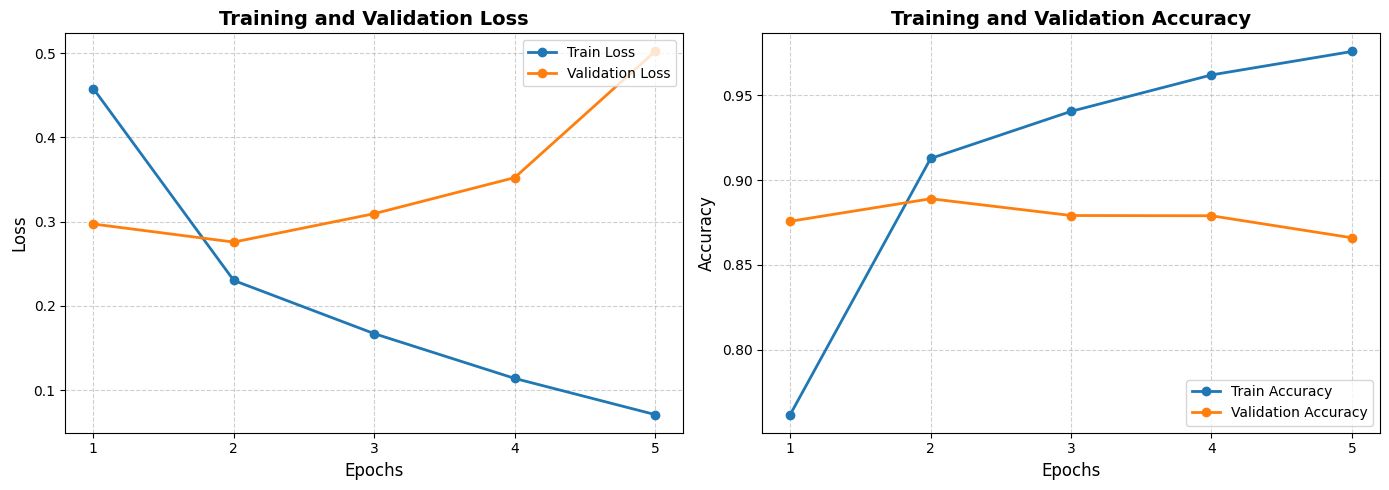

In [ ]:
plt.figure(figsize=(14, 5))

# Tạo mảng số thứ tự Epochs bắt đầu từ 1 (ví dụ: 1, 2, 3) để trục X đẹp hơn
epochs_range = range(1, len(history.history['loss']) + 1)

# ĐỒ THỊ 1: LOSS (Đưa sang bên trái)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], label='Train Loss',
         color='#1f77b4', linewidth=2, marker='o', markersize=6) # marker='o' tạo dấu chấm tròn
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss',
         color='#ff7f0e', linewidth=2, marker='o', markersize=6)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs_range) # Ép trục X chỉ hiện số nguyên 1, 2, 3...
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# ĐỒ THỊ 2: ACCURACY (Đưa sang bên phải)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy',
         color='#1f77b4', linewidth=2, marker='o', markersize=6)
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy',
         color='#ff7f0e', linewidth=2, marker='o', markersize=6)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(epochs_range)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


--- PLOTTING EVALUATION METRICS ---
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


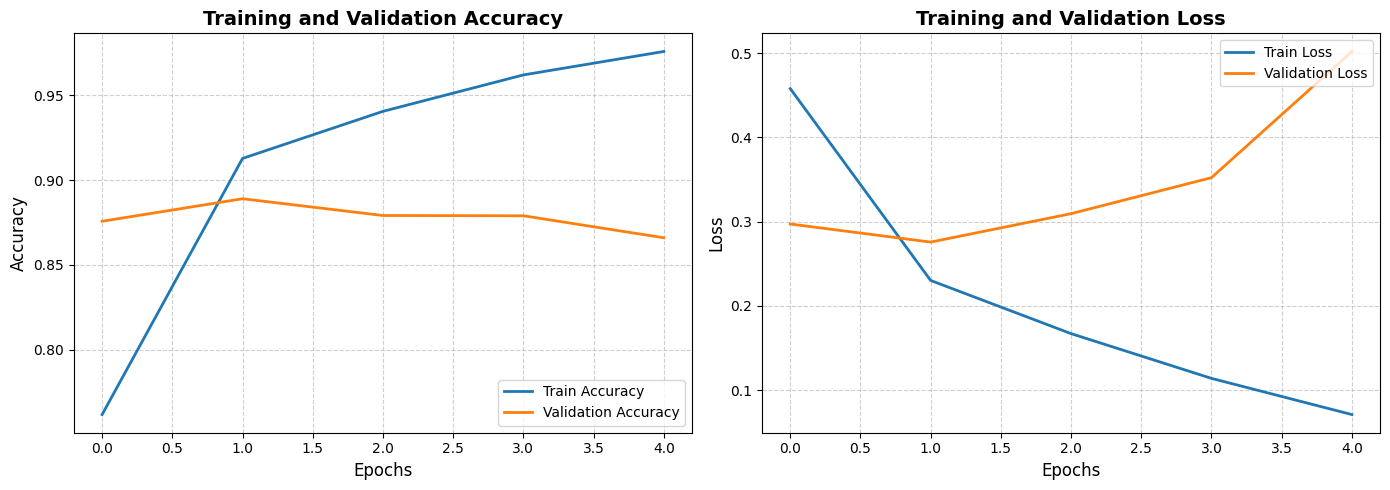

In [ ]:
print("\n--- PLOTTING EVALUATION METRICS ---")

# Dự đoán trên tập Test
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int)

# 4.1. Accuracy and Loss Plots
plt.figure(figsize=(14, 5))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

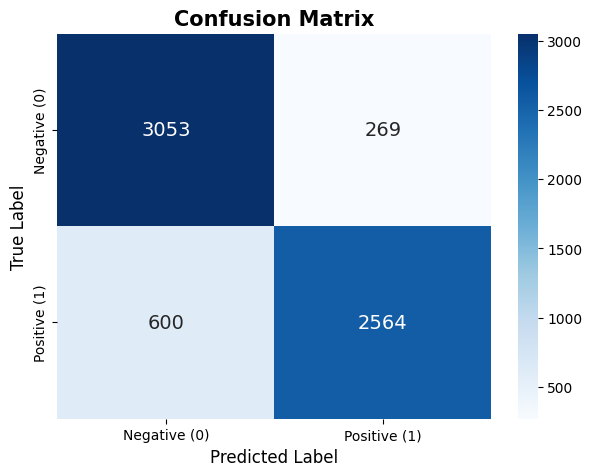


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.84      0.92      0.88      3322
    Positive       0.91      0.81      0.86      3164

    accuracy                           0.87      6486
   macro avg       0.87      0.86      0.87      6486
weighted avg       0.87      0.87      0.87      6486



In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def foolproof_attention(text_sample):
    print("1. Đang tiền xử lý văn bản...")
    cleaned_text = clean_text(text_sample)
    words = cleaned_text.split()

    if len(words) == 0:
        print("Lỗi: Câu review này không hợp lệ (toàn ký tự rỗng hoặc stopwords).")
        return

    seq = tokenizer.texts_to_sequences([cleaned_text])
    pad_seq = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')

    print("2. Đang chạy mô hình dự đoán (BiGRU + Attention)...")
    # Tắt verbose để tránh in log thanh quá trình
    pred_prob = model.predict(pad_seq, verbose=0)[0][0]
    sentiment = "Positive" if pred_prob > 0.5 else "Negative"

    # Trích xuất trọng số
    weights = attention_extractor.predict(pad_seq, verbose=0)[0]
    word_weights = weights[-len(words):].flatten()

    # ==========================================
    # PHẦN 1: IN KẾT QUẢ RA CONSOLE (CHẮC CHẮN HIỆN)
    # ==========================================
    print("\n" + "="*40)
    print(f"🎯 KẾT QUẢ DỰ ĐOÁN: {sentiment}")
    print(f"📊 ĐỘ TỰ TIN (Probability): {pred_prob:.4f}")
    print("="*40)
    print("MỨC ĐỘ CHÚ Ý CỦA AI VÀO TỪNG TỪ (0.0 -> 1.0):")

    # In ra dạng bảng text cực kỳ rõ ràng
    for w, weight in zip(words, word_weights):
        # Nhân giả lập lên một chút để số dễ nhìn hơn (tùy chọn)
        print(f" - {w:<15} : {weight:.4f}")
    print("="*40)

    # ==========================================
    # PHẦN 2: VẼ BIỂU ĐỒ CỘT CƠ BẢN NHẤT
    # ==========================================
    print("\n3. Đang render biểu đồ...")

    fig, ax = plt.subplots(figsize=(10, 5)) # Buộc tạo mới một khung tranh

    x_pos = np.arange(len(words))

    # Vẽ cột màu đỏ đậm
    ax.bar(x_pos, word_weights, color='firebrick', alpha=0.8)

    # Thiết lập trục X là các chữ cái
    ax.set_xticks(x_pos)
    ax.set_xticklabels(words, rotation=45, ha='right', fontsize=12, fontweight='bold')

    # Trang trí
    ax.set_ylabel('Attention Score', fontsize=12)
    ax.set_title(f'Attention Weight of model (Predicted: {sentiment})', fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


--- PLOTTING ATTENTION HEATMAP ---
1. Đang tiền xử lý văn bản...
2. Đang chạy mô hình dự đoán (BiGRU + Attention)...

🎯 KẾT QUẢ DỰ ĐOÁN: Negative
📊 ĐỘ TỰ TIN (Probability): 0.0001
MỨC ĐỘ CHÚ Ý CỦA AI VÀO TỪNG TỪ (0.0 -> 1.0):
 - movie           : 0.0273
 - absolutely      : 0.0290
 - terrible        : 0.0287
 - plot            : 0.0288
 - completely      : 0.0283
 - predictable     : 0.0288
 - acting          : 0.0280
 - awful           : 0.0271
 - wasted          : 0.0142
 - two             : 0.0056
 - hours           : 0.0051
 - life            : 0.0081

3. Đang render biểu đồ...


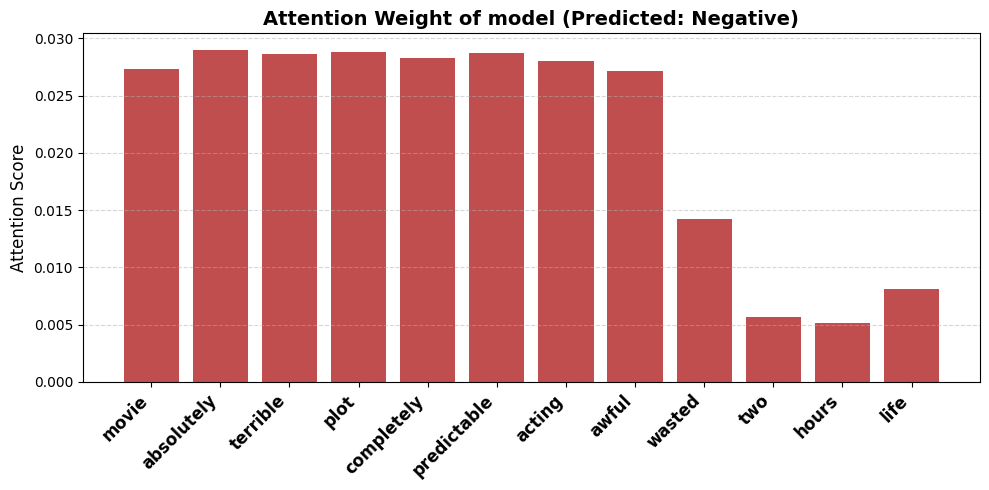

In [ ]:
# TEST MÔ HÌNH VỚI MỘT CÂU REVIEW
test_review = "This movie is absolutely terrible. The plot was completely predictable and the acting was awful. I wasted two hours of my life."
print("\n--- PLOTTING ATTENTION HEATMAP ---")
foolproof_attention(test_review)